DATA BASE DESIGN PROJECT
NAME- DARNA HRUSHITHA                                       STUDENT ID- 02145279

# OBJECTIVE
The objective of this project is to develop a program that measures the time taken for various queries on large CSV files using embedded databases and analyze the performance of their queries on different file sizes and document their findings in a final report.


#Steps to Import CSV Data into SQLite Using Terminal Commands

Navigate to the Project Directory

In [ ]:
cd /Users/hrushitha/Desktop/dbdesignproj

# SET UP AND INSTALLATION
In the terminal on my MAC , A virtual environment is set up in bash script
source venv/bin/activate
and then packages that are required are installed
pip install matplotlib

In [ ]:
source myenv/bin/activate 
pip install matplotlib

Open SQLite for the 1MB Data File

In [ ]:
sqlite3 salary_data_1MB

Set the Mode to CSV

In [ ]:
.mode csv

Import the 1MB CSV File into the salary_data Table

In [ ]:
import /Users/hrushitha/Desktop/dbdesignproj/salary_tracker_1MB.csv salary_data

Verify the Table Creation

In [ ]:
.table

#Repeat for 10MB and 100MB Files

In [ ]:
sqlite3 salary_data_10MB
.mode csv
import /Users/hrushitha/Desktop/dbdesignproj/salary_tracker_10MB.csv salary_data
.table

In [ ]:
sqlite3 salary_data_100MB
.mode csv
import /Users/hrushitha/Desktop/dbdesignproj/salary_tracker_100MB.csv salary_data
.table

 #SQLite Queries

query-1
This query is used to find individuals who were born before 1975 and whose latest earnings exceed $130,000. The subquery ensures that only the most recent earning year is considered for each person.

In [ ]:
SELECT PersonName
FROM salary_data
WHERE BirthDate < '1975-01-01'
  AND Earnings > 130000
  AND EarningsYear = (SELECT MAX(EarningsYear) 
                      FROM salary_data 
                      WHERE PersonID = salary_data.PersonID);

query-2
This query identifies individuals who have earned more than $400,000 at any time in their careers and are currently not working. It helps to find high-earning former employees.

In [ ]:
SELECT DISTINCT PersonName, SchoolName
FROM salary_data
WHERE Earnings > 400000
  AND StillWorking = 'no';

query-3
This query filters out the names of individuals who served as Lecturers at the University of Texas and are no longer active. It helps identify past lecturers at a specific institution.

In [ ]:
SELECT DISTINCT PersonName
FROM salary_data
WHERE SchoolName = 'University of Texas'
  AND JobTitle = 'Lecturer'
  AND StillWorking = 'no';

query-4
This query determines which university and campus have the highest number of active faculty members. It groups records by university and campus and orders them by the count of active employees in descending order.

In [ ]:
SELECT SchoolName, SchoolCampus, COUNT(*) AS active_count
FROM salary_data
WHERE StillWorking = 'yes'
GROUP BY SchoolName, SchoolCampus
ORDER BY active_count DESC
LIMIT 1;

query-5
This query retrieves the most recent job details and earnings for an individual named "Hrushitha DARNA." The results are sorted by the earnings year in descending order to show the latest record.

In [ ]:
SELECT PersonName, JobTitle, DepartmentName, SchoolName, Earnings
FROM salary_data
WHERE PersonName = 'Hrushitha DARNA'
ORDER BY EarningsYear DESC
LIMIT 1;

query-6
This query calculates the average earnings for each department and identifies the department with the highest average earnings. The results are grouped by department and ordered by average earnings in descending order.

In [ ]:
SELECT DepartmentName, AVG(Earnings) AS avg_earnings
FROM salary_data
GROUP BY DepartmentName
ORDER BY avg_earnings DESC
LIMIT 1;

# After running the above queries, exit SQLite and create a Python script for performance analysis using a Bash script

For jupyter notebook read.me file while the virtual environment is active, install the ipykernel package

In [ ]:
pip install ipykernel

Adding the virtual environment as a Jupyter kernel

In [ ]:
python -m ipykernel install --user --name=myenv --display-name "MyEnv"

name=myenv is the name used.
display-name "MyEnv" is how it will appear in Jupyter Notebook.

In [ ]:
vi query_performance_analysis.py

Press i to enter insert mode


Running queries on 1MB database...
Query 1 on 1MB: 0.0028 seconds
Query 2 on 1MB: 0.0014 seconds
Query 3 on 1MB: 0.0004 seconds
Query 4 on 1MB: 0.0004 seconds
Query 5 on 1MB: 0.0003 seconds
Query 6 on 1MB: 0.0015 seconds

Running queries on 10MB database...
Query 1 on 10MB: 0.0257 seconds
Query 2 on 10MB: 0.0141 seconds
Query 3 on 10MB: 0.0046 seconds
Query 4 on 10MB: 0.0047 seconds
Query 5 on 10MB: 0.0034 seconds
Query 6 on 10MB: 0.0195 seconds

Running queries on 100MB database...
Query 1 on 100MB: 0.1637 seconds
Query 2 on 100MB: 0.1313 seconds
Query 3 on 100MB: 0.0483 seconds
Query 4 on 100MB: 0.0505 seconds
Query 5 on 100MB: 0.0418 seconds
Query 6 on 100MB: 0.2271 seconds


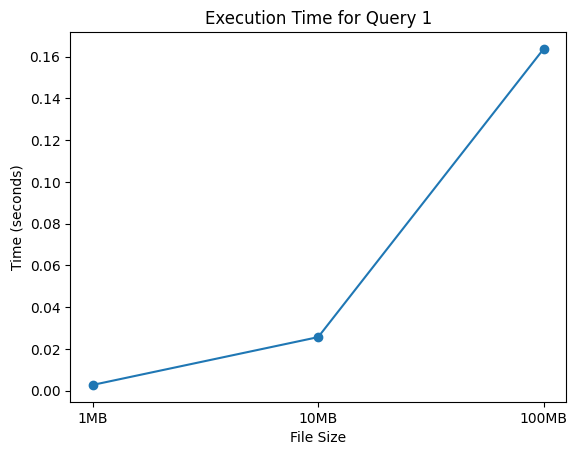

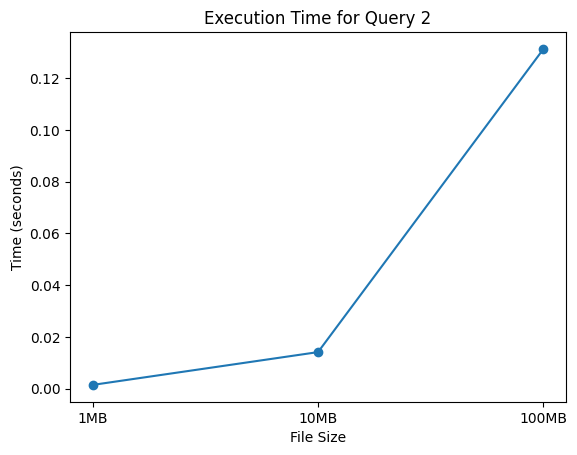

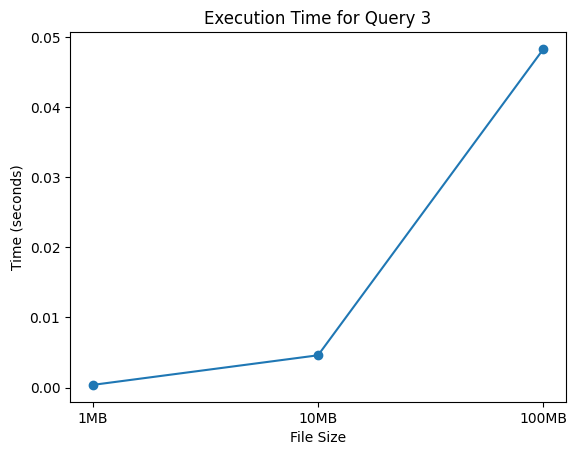

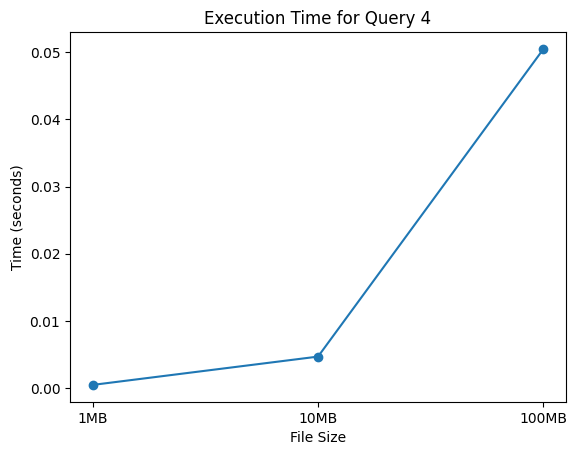

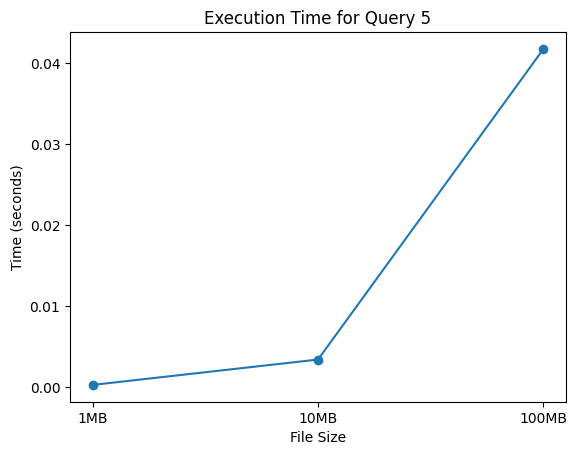

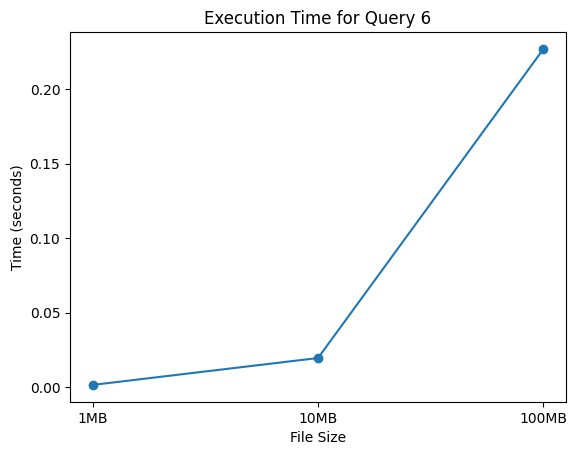

In [1]:
import sqlite3
import time
import matplotlib.pyplot as plt

# Database paths for the three file sizes
db_files = {
    "1MB": "/Users/hrushitha/Desktop/dbdesignproj/salary_data_1MB.db",
    "10MB": "/Users/hrushitha/Desktop/dbdesignproj/salary_data_10MB.db",
    "100MB": "/Users/hrushitha/Desktop/dbdesignproj/salary_data_100MB.db"
}

# Corrected queries to execute and measure
queries = {
    # Query 1: Show the name of all people born before 1975 whose most recent earning is more than $130,000
    "Query 1": """SELECT PersonName
                  FROM salary_data
                  WHERE BirthDate < '1975-01-01'
                    AND Earnings > 130000
                    AND EarningsYear = (SELECT MAX(EarningsYear) 
                                        FROM salary_data 
                                        WHERE PersonID = salary_data.PersonID);""",
    
    # Query 2: Show the names and school names of all people who made more than $400,000 at any point in their career and are not active.
    "Query 2": """SELECT DISTINCT PersonName, SchoolName
                  FROM salary_data
                  WHERE Earnings > 400000
                    AND StillWorking = 'no';""",
    
    # Query 3: Show the names of all people who worked at the University of Texas as Lecturers and are not active.
    "Query 3": """SELECT DISTINCT PersonName
                  FROM salary_data
                  WHERE SchoolName = 'University of Texas'
                    AND JobTitle = 'Lecturer'
                    AND StillWorking = 'no';""",
    
    # Query 4: Show the University and campus pair that has the most active faculty members.
    "Query 4": """SELECT SchoolName, SchoolCampus, COUNT(*) AS active_count
                  FROM salary_data
                  WHERE StillWorking = 'yes'
                  GROUP BY SchoolName, SchoolCampus
                  ORDER BY active_count DESC
                  LIMIT 1;""",
    
    # Query 5: Search for the latest job details and earnings of a specific individual named "Hrushitha DARNA".
    "Query 5": """SELECT PersonName, JobTitle, DepartmentName, SchoolName, Earnings
                  FROM salary_data
                  WHERE PersonName = 'Hrushitha DARNA'
                  ORDER BY EarningsYear DESC
                  LIMIT 1;""",
    
    # Query 6: Show the department with the highest average earnings.
    "Query 6": """SELECT DepartmentName, AVG(Earnings) AS avg_earnings
                  FROM salary_data
                  GROUP BY DepartmentName
                  ORDER BY avg_earnings DESC
                  LIMIT 1;"""
}

# Dictionary to store the execution times for each query
results = {query_name: [] for query_name in queries}

# Measure execution time of each query on each database
for db_size, db_path in db_files.items():
    conn = sqlite3.connect(db_path)
    cursor = conn.cursor()
    
    print(f"\nRunning queries on {db_size} database...")
    for query_name, query in queries.items():
        start_time = time.time()
        cursor.execute(query)
        cursor.fetchall()  # Ensure the query is fully executed
        execution_time = time.time() - start_time
        
        # Store the execution time for graphing
        results[query_name].append((db_size, execution_time))
        
        # Print the time taken for each query on each database
        print(f"{query_name} on {db_size}: {execution_time:.4f} seconds")
    
    conn.close()

# Plotting the results
for query_name, timings in results.items():
    file_sizes = [size for size, _ in timings]
    times = [time for _, time in timings]
    
    plt.figure()
    plt.plot(file_sizes, times, marker='o')
    plt.title(f"Execution Time for {query_name}")
    plt.xlabel("File Size")
    plt.ylabel("Time (seconds)")
    plt.show()



Running the Code

Save the code in a Python file named query_performance_analysis.py.

Exit the editor by using :wq.

Run the code in the terminal with the following command:

In [ ]:
python3 query_performance_analysis.py

For jupyter notebook , launch it for a READ.ME file. The command is:

In [ ]:
jupyter notebook

#Expected Output

After running the code, you will see six graphs, each representing the execution time for one of the six queries across the three database file sizes (1MB, 10MB, and 100MB). And slso, the runtime for each query on each database size will be displayed. The runtime provides insights into the query performance across different data volumes.

